# Partial-Equilibrium MC vs TM for MarkovConsumerType

This notebook compares **Monte Carlo** simulation (`initialize_sym()` / `symulate()` / `hystory`)
with **transition-matrix** (TM) methods for `MarkovConsumerType` models of
increasing complexity:

| Part | Model | TM grid | Key challenge |
|------|-------|---------|---------------|
| 1 | 4-state serial unemployment | 1D over $m$ | Multiple discrete states |
| 2 | 5-state varying PermGroFac | 2D over $(m, p)$ | Non-degenerate $p$ distribution |
| 3 | Same model, Harmenberg measure | 1D over $m$ | Neutral measure collapses $p$ dimension |

Each part sets up a model, runs MC, builds a TM, and compares aggregate
statistics, time-series paths, and cross-sectional distributions.

See also: `examples/SequenceSpaceJacobians/Transition_Matrix_Example.ipynb`
for the `NewKeynesianConsumerType` version of these comparisons.


In [1]:
import time
from copy import copy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import scipy.sparse.linalg as sp_linalg

from HARK.ConsumptionSaving.ConsMarkovModel import (
    MarkovConsumerType,
    init_indshk_markov,
)
from HARK.Calibration.Income.IncomeProcesses import (
    construct_lognormal_income_process_unemployment,
)
from HARK.distributions import DiscreteDistributionLabeled
from HARK.utilities import make_grid_exp_mult, jump_to_grid_1D, jump_to_grid_2D

COLOR_MC = "tab:blue"
COLOR_TM = "tab:orange"
BURNIN = 400
N_MC_BINS = 200

---
# Part 1: Serial Unemployment (4-State Markov, 1D Grid)


## 1. Model Setup

We construct the 4×4 Markov transition matrix from economic primitives:
average unemployment spell length, unemployment rates in boom/bust, and
transition probabilities between macro states.

**HARK convention:** `MrkvArray` is row-stochastic — `MrkvArray[i, j]`
= P(transition to state $j$ | currently in state $i$).

**Calibration:** Starts from HARK's `init_indshk_markov` defaults, then
overrides with custom values chosen for illustration: `Rfree = 1.03`,
`LivPrb = 0.98`, `PermGroFac = 1.0` (all states identical).  Income
distributions are degenerate: employed agents get $\theta = 1$, unemployed
get $\theta = 0$.  The Markov transition matrix is built from labor-market
primitives (unemployment spell length, unemployment rates, business-cycle
transition probabilities) chosen for pedagogical clarity.

In [2]:
unemp_length = 5  # Average length of unemployment spell
urate_good = 0.05  # Unemployment rate in boom
urate_bad = 0.12  # Unemployment rate in bust
bust_prob = 0.01  # P(boom -> bust) per period
recession_length = 20  # Average length of bust

p_reemploy = 1.0 / unemp_length
p_unemploy_good = p_reemploy * urate_good / (1 - urate_good)
p_unemploy_bad = p_reemploy * urate_bad / (1 - urate_bad)
boom_prob = 1.0 / recession_length

# Row-stochastic: MrkvArray[i, j] = P(go to j | in i)
# States: 0=emp-boom, 1=unemp-boom, 2=emp-bust, 3=unemp-bust
MrkvArray = np.array(
    [
        [
            (1 - p_unemploy_good) * (1 - bust_prob),
            p_unemploy_good * (1 - bust_prob),
            (1 - p_unemploy_good) * bust_prob,
            p_unemploy_good * bust_prob,
        ],
        [
            p_reemploy * (1 - bust_prob),
            (1 - p_reemploy) * (1 - bust_prob),
            p_reemploy * bust_prob,
            (1 - p_reemploy) * bust_prob,
        ],
        [
            (1 - p_unemploy_bad) * boom_prob,
            p_unemploy_bad * boom_prob,
            (1 - p_unemploy_bad) * (1 - boom_prob),
            p_unemploy_bad * (1 - boom_prob),
        ],
        [
            p_reemploy * boom_prob,
            (1 - p_reemploy) * boom_prob,
            p_reemploy * (1 - boom_prob),
            (1 - p_reemploy) * (1 - boom_prob),
        ],
    ]
)

J = 4
state_names = ["Emp-Boom", "Unemp-Boom", "Emp-Bust", "Unemp-Bust"]

print("Markov transition matrix (row-stochastic):")
print(np.array2string(MrkvArray, precision=4, suppress_small=True))
print(f"Row sums: {MrkvArray.sum(axis=1)}")

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(MrkvArray.T)
idx = np.argmin(np.abs(eigvals - 1.0))
markov_stationary = eigvecs[:, idx].real
markov_stationary = markov_stationary / markov_stationary.sum()
print("\nStationary distribution:")
for j in range(J):
    print(f"  {state_names[j]:15s}: {markov_stationary[j]:.4f}")

Markov transition matrix (row-stochastic):
[[0.9796 0.0104 0.0099 0.0001]
 [0.198  0.792  0.002  0.008 ]
 [0.0486 0.0014 0.9241 0.0259]
 [0.01   0.04   0.19   0.76  ]]
Row sums: [1. 1. 1. 1.]

Stationary distribution:
  Emp-Boom       : 0.7894
  Unemp-Boom     : 0.0440
  Emp-Bust       : 0.1488
  Unemp-Bust     : 0.0179


## 2. Solve the Model

In [3]:
# Start from HARK's init_indshk_markov defaults, then customize for 4-state model
params = copy(init_indshk_markov)
params["cycles"] = 0  # infinite horizon
params["AgentCount"] = 100000
params["T_sim"] = 1200
params["Rfree"] = [np.array([1.03, 1.03, 1.03, 1.03])]
params["LivPrb"] = [np.array([0.98, 0.98, 0.98, 0.98])]
params["PermGroFac"] = [np.array([1.0, 1.0, 1.0, 1.0])]  # 1D grid
params["MrkvPrbsInit"] = markov_stationary
params["Mrkv_p11"] = [0.5]  # placeholder — will be overridden
params["Mrkv_p22"] = [0.5]
params["UnempPrb"] = np.zeros(2)  # no extra unemployment on top of Markov
params["global_markov"] = False

agent = MarkovConsumerType(**params)

# Override MrkvArray with our 4×4 matrix AFTER construction
agent.assign_parameters(MrkvArray=[MrkvArray])

# Override income distributions: degenerate (deterministic given state)
employed_income = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [1.0]]),
    var_names=["PermShk", "TranShk"],
)
unemployed_income = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.0]]),
    var_names=["PermShk", "TranShk"],
)
agent.IncShkDstn = [
    [
        employed_income,  # state 0: employed-boom
        unemployed_income,  # state 1: unemployed-boom
        employed_income,  # state 2: employed-bust
        unemployed_income,  # state 3: unemployed-bust
    ]
]

# Re-build terminal solution for 4 states (constructor made it for 2)
from HARK.ConsumptionSaving.ConsMarkovModel import make_markov_solution_terminal

agent.solution_terminal = make_markov_solution_terminal(agent.CRRA, agent.MrkvArray)

agent.solve()
print(f"Solved: {len(agent.solution[0].cFunc)} consumption functions")

Solved: 4 consumption functions


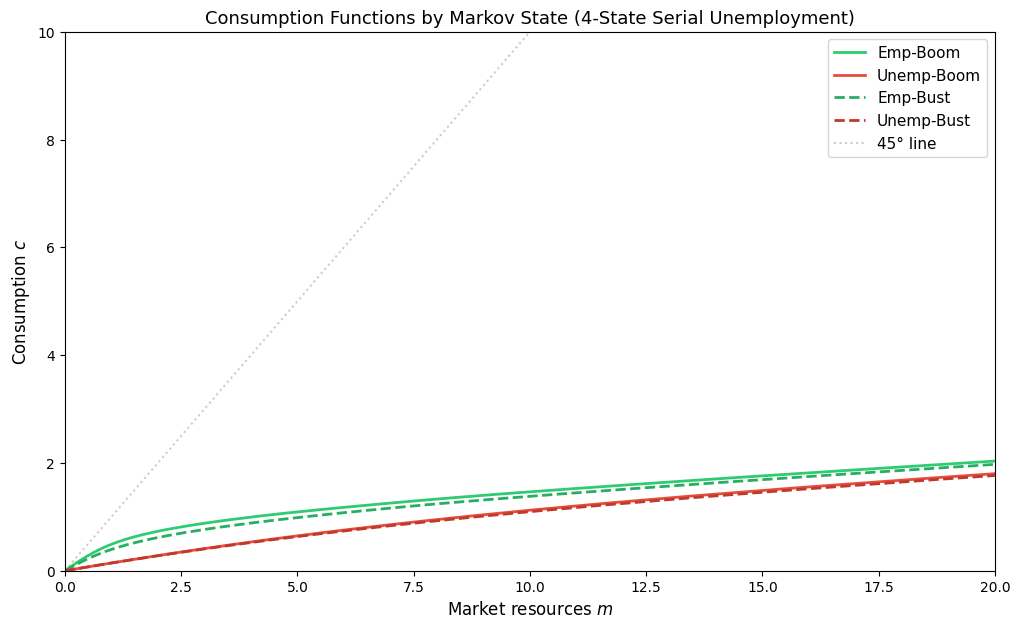

In [4]:
# [consumption_functions_by_state]
m_plot = np.linspace(0.001, 20, 300)

plt.figure(figsize=(12, 7))
colors = ["#2ecc71", "#e74c3c", "#27ae60", "#c0392b"]
styles = ["-", "-", "--", "--"]
for j in range(J):
    c_vals = agent.solution[0].cFunc[j](m_plot)
    plt.plot(
        m_plot,
        c_vals,
        label=state_names[j],
        linewidth=2,
        color=colors[j],
        linestyle=styles[j],
    )
plt.plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
plt.xlabel("Market resources $m$", fontsize=12)
plt.ylabel("Consumption $c$", fontsize=12)
plt.title(
    "Consumption Functions by Markov State (4-State Serial Unemployment)", fontsize=13
)
plt.legend(fontsize=11)
plt.xlim([0, 20])
plt.ylim([0, 10])
plt.show()

## 3. Monte Carlo Simulation

We use the YAML-backed simulator: **`initialize_sym()`** then **`symulate()`**, with tracked series in **`hystory`** (the modern replacement for legacy `history`).
Same pattern as `examples/SequenceSpaceJacobians/Transition_Matrix_Example.ipynb`.


In [5]:
agent.track_vars = ["aNrm", "cNrm", "mNrm", "pLvl", "Mrkv"]

t0_mc = time.time()
agent.initialize_sym()
agent.symulate()
mc_sim_time = time.time() - t0_mc

n_agents = agent.AgentCount
HY = agent.hystory
t_last = -1
MC_C = np.mean(HY["mNrm"][t_last] - HY["aNrm"][t_last])
MC_A = np.mean(HY["aNrm"][t_last])

print(f"MC simulation: {mc_sim_time:.2f}s ({n_agents:,} agents, {agent.T_sim} periods)")
print(f"MC Aggregate Consumption = {MC_C:.6f}")
print(f"MC Aggregate Assets      = {MC_A:.6f}")
print()
for j in range(J):
    frac = np.mean(HY["Mrkv"][t_last] == j)
    print(
        f"{state_names[j]:15s}: MC frac = {frac:.4f}, "
        f"stationary = {markov_stationary[j]:.4f}"
    )

MC simulation: 25.48s (100,000 agents, 1200 periods)
MC Aggregate Consumption = 0.969969
MC Aggregate Assets      = 3.405530

Emp-Boom       : MC frac = 0.7898, stationary = 0.7894
Unemp-Boom     : MC frac = 0.0438, stationary = 0.0440
Emp-Bust       : MC frac = 0.1489, stationary = 0.1488
Unemp-Bust     : MC frac = 0.0176, stationary = 0.0179


In [6]:
mc_aLvls = np.array([np.mean(agent.hystory["aNrm"][t]) for t in range(agent.T_sim)])

## 4. Transition Matrix Construction

The joint state is $(m, j)$ with $j \in \{0,1,2,3\}$ and $m$ on a
grid of $M$ points.  Total TM size: $(4M)^2$.

Since income distributions are degenerate (1 shock point per state),
each source grid point maps to at most 2 target grid points via the lottery.
This makes the TM very sparse.

In [7]:
mMin = 0.001
mMax = 50
mCount = 300
mFac = 3

dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)

M = len(dist_mGrid)
N_states = M * J

print(f"m-grid: {M} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")
print(f"Markov states: {J}")
print(f"Total TM states: {N_states}")

m-grid: 300 points from 0.0010 to 50.0
Markov states: 4
Total TM states: 1200


In [8]:
start = time.time()

MrkvArr = agent.MrkvArray[0]
Rfree_arr = agent.Rfree[0]
LivPrb_arr = agent.LivPrb[0]
PermGroFac_arr = agent.PermGroFac[0]
IncShkDstn_list = agent.IncShkDstn[0]

# Policy on grid
cPol = []
aPol = []
for j in range(J):
    c_j = agent.solution[0].cFunc[j](dist_mGrid)
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPol.append(c_j)
    aPol.append(a_j)

# Newborn distribution
MrkvPrbsInit = markov_stationary
NewBornDist = np.zeros(N_states)
for jp in range(J):
    shk_dstn = IncShkDstn_list[jp]
    newborn_m = jump_to_grid_1D(shk_dstn.atoms[1], shk_dstn.pmv, dist_mGrid)
    NewBornDist[jp * M : (jp + 1) * M] = MrkvPrbsInit[jp] * newborn_m

# Build transition matrix
# MrkvArr[j, jp] = P(j -> jp) [row-stochastic]
TranMatrix = np.zeros((N_states, N_states))

for j in range(J):
    a_grid = aPol[j]
    LivPrb_j = LivPrb_arr[j]

    for jp in range(J):
        markov_prob = MrkvArr[j, jp]
        if markov_prob < 1e-15:
            continue

        Rfree_jp = Rfree_arr[jp]
        PermGroFac_jp = PermGroFac_arr[jp]
        shk_dstn = IncShkDstn_list[jp]
        shk_prbs = shk_dstn.pmv
        perm_shks = shk_dstn.atoms[0]
        tran_shks = shk_dstn.atoms[1]
        bNext = Rfree_jp * a_grid

        for i in range(M):
            mNext = bNext[i] / (perm_shks * PermGroFac_jp) + tran_shks
            lottery_weights = jump_to_grid_1D(mNext, shk_prbs, dist_mGrid)
            src_idx = j * M + i
            TranMatrix[jp * M : (jp + 1) * M, src_idx] += (
                markov_prob * LivPrb_j * lottery_weights
            )

    for i in range(M):
        src_idx = j * M + i
        TranMatrix[:, src_idx] += (1.0 - LivPrb_j) * NewBornDist

tm_build_time = time.time() - start
print(f"Transition matrix built in {tm_build_time:.2f}s")
print(f"Shape: {TranMatrix.shape}")
col_sums = TranMatrix.sum(axis=0)
print(f"Column sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

nnz = np.count_nonzero(TranMatrix)
total = N_states * N_states
print(f"Non-zero entries: {nnz} / {total} ({100 * nnz / total:.2f}%)")

Transition matrix built in 0.92s
Shape: (1200, 1200)
Column sums: min=1.00000000, max=1.00000000
Non-zero entries: 16634 / 1440000 (1.16%)


## 5. Ergodic Distribution

In [9]:
start = time.time()
eigenvalues, eigenvectors = sp_linalg.eigs(
    TranMatrix, k=1, which="LM", v0=np.ones(N_states)
)
ergodic_dist = eigenvectors[:, 0].real
ergodic_dist = ergodic_dist / ergodic_dist.sum()

tm_ergo_time = time.time() - start
print(f"Ergodic distribution computed in {tm_ergo_time:.2f}s")
print()
for j in range(J):
    mass_j = ergodic_dist[j * M : (j + 1) * M].sum()
    print(
        f"{state_names[j]:15s}: TM mass = {mass_j:.4f}, "
        f"stationary = {markov_stationary[j]:.4f}"
    )

tm_total_time = tm_build_time + tm_ergo_time
print("\n--- Timing Summary ---")
print(f"MC simulation:    {mc_sim_time:.2f}s ({n_agents:,} agents)")
print(f"TM build + ergo:  {tm_total_time:.2f}s ({mCount} m-pts × {J} states)")
print(f"Speedup:          {mc_sim_time / tm_total_time:.1f}×")

Ergodic distribution computed in 0.03s

Emp-Boom       : TM mass = 0.7894, stationary = 0.7894
Unemp-Boom     : TM mass = 0.0440, stationary = 0.0440
Emp-Bust       : TM mass = 0.1488, stationary = 0.1488
Unemp-Bust     : TM mass = 0.0179, stationary = 0.0179

--- Timing Summary ---
MC simulation:    25.48s (100,000 agents)
TM build + ergo:  0.95s (300 m-pts × 4 states)
Speedup:          26.8×


In [10]:
TM_C = sum(np.dot(cPol[j], ergodic_dist[j * M : (j + 1) * M]) for j in range(J))
TM_A = sum(np.dot(aPol[j], ergodic_dist[j * M : (j + 1) * M]) for j in range(J))

print(f"TM Aggregate Consumption = {TM_C:.6f}")
print(f"TM Aggregate Assets      = {TM_A:.6f}")

TM Aggregate Consumption = 0.970207
TM Aggregate Assets      = 3.408579


## 6. Comparison

In [11]:
print("=== Aggregate Comparison ===")
print(f"{'':20s} {'MC':>12s} {'TM':>12s} {'Diff':>12s}")
print(f"{'Consumption':20s} {MC_C:12.6f} {TM_C:12.6f} {MC_C - TM_C:12.6f}")
print(f"{'Assets':20s} {MC_A:12.6f} {TM_A:12.6f} {MC_A - TM_A:12.6f}")

=== Aggregate Comparison ===
                               MC           TM         Diff
Consumption              0.969969     0.970207    -0.000237
Assets                   3.405530     3.408579    -0.003049


### Time series comparison

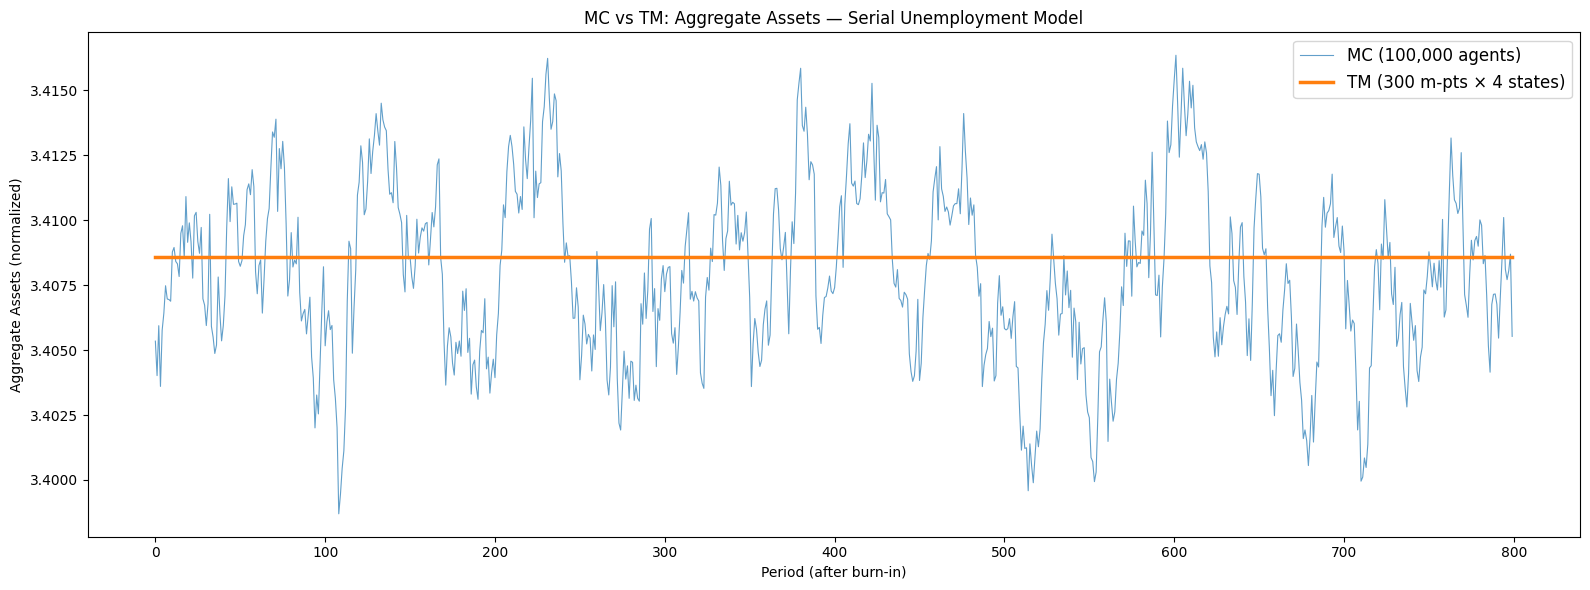

In [12]:
# [mc_vs_tm_asset_paths]
dstn = ergodic_dist.copy()
tm_aLvls = []
for t in range(agent.T_sim - BURNIN):
    A_val = sum(np.dot(aPol[j], dstn[j * M : (j + 1) * M]) for j in range(J))
    tm_aLvls.append(A_val)
    dstn = TranMatrix @ dstn

plt.figure(figsize=(16, 6))
plt.plot(
    mc_aLvls[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC ({n_agents:,} agents)",
)
plt.plot(
    tm_aLvls, color=COLOR_TM, linewidth=2.5, label=f"TM ({mCount} m-pts × {J} states)"
)
plt.xlabel("Period (after burn-in)")
plt.ylabel("Aggregate Assets (normalized)")
plt.title("MC vs TM: Aggregate Assets — Serial Unemployment Model")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Distribution of $m$ by Markov state

With degenerate income (unemployed get exactly 0), the unemployed distribution
should show a sharp spike near $m = 0$ — all their market resources come from
prior savings times $R$.

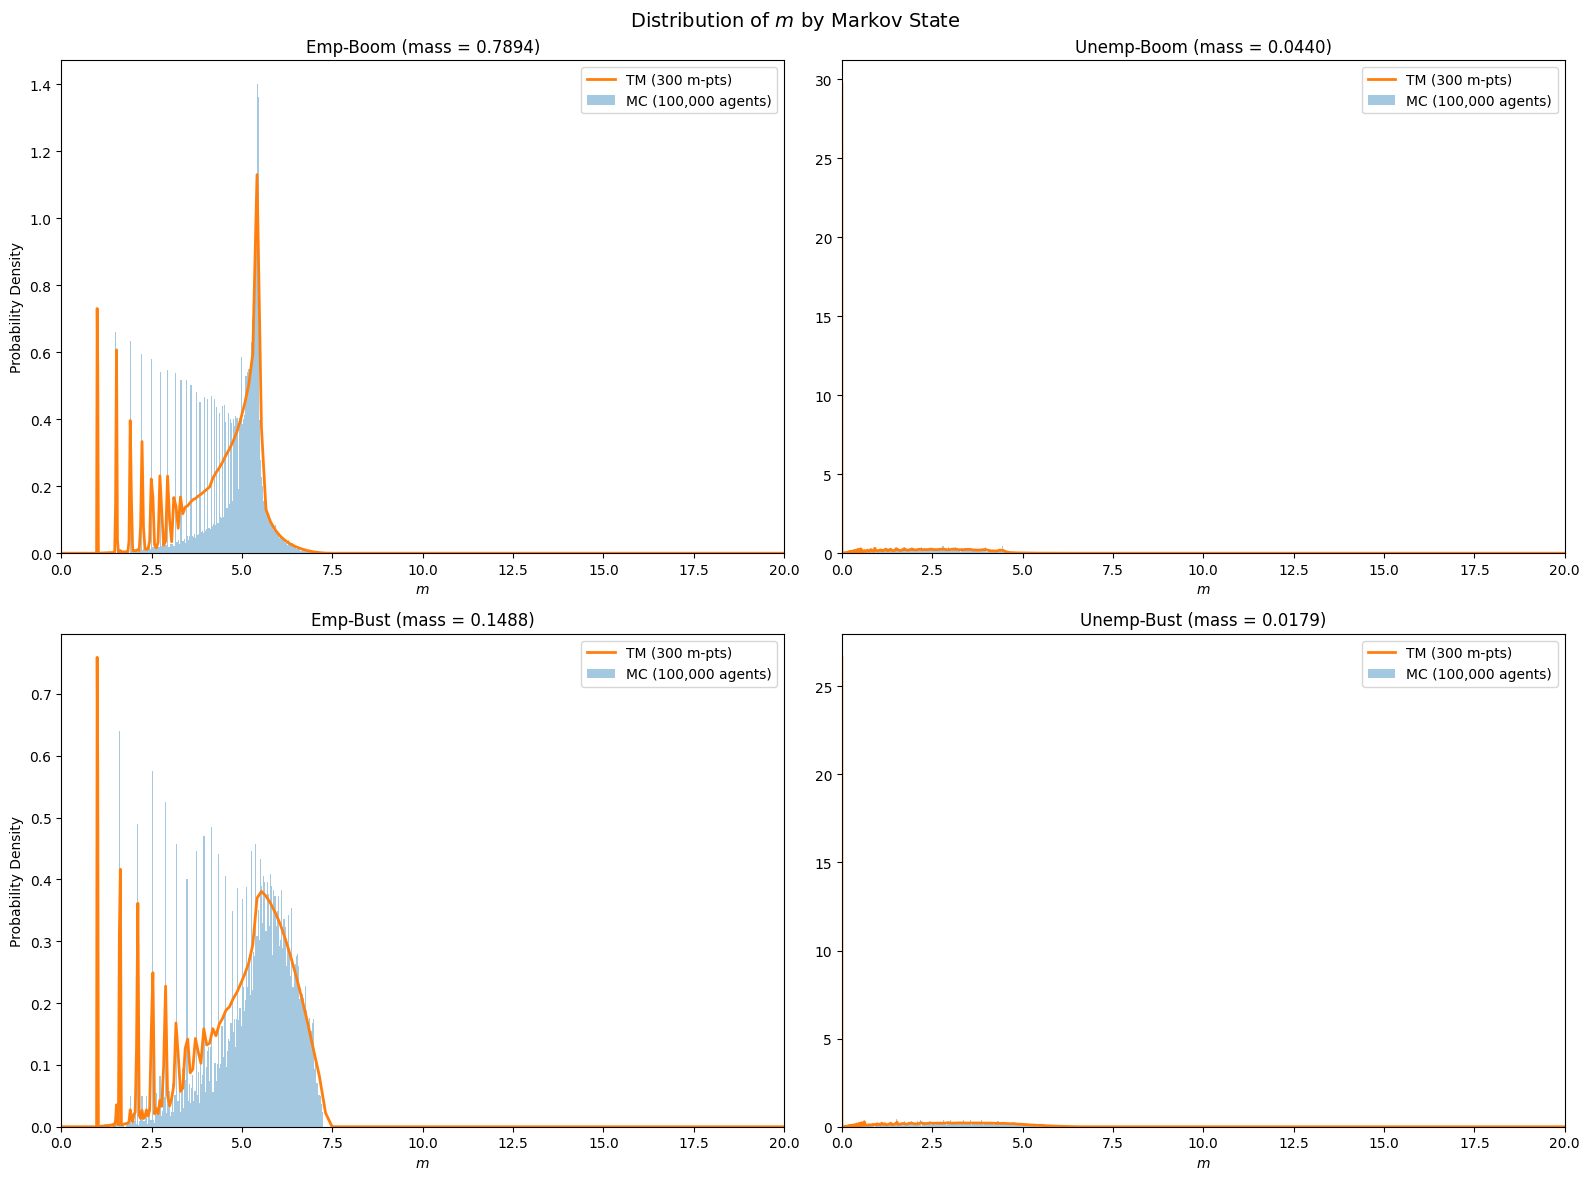

In [13]:
# [dist_normalized_market_resources_by_state]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

midpoint_widths = np.zeros(M)
midpoint_widths[0] = dist_mGrid[1] - dist_mGrid[0]
midpoint_widths[-1] = dist_mGrid[-1] - dist_mGrid[-2]
midpoint_widths[1:-1] = 0.5 * (dist_mGrid[2:] - dist_mGrid[:-2])

for j in range(J):
    ax = axes[j // 2][j % 2]
    p_j = ergodic_dist[j * M : (j + 1) * M]
    mass_j = p_j.sum()
    p_j_cond = p_j / mass_j if mass_j > 0 else p_j
    tm_density = p_j_cond / midpoint_widths

    ax.plot(
        dist_mGrid,
        tm_density,
        color=COLOR_TM,
        linewidth=2,
        label=f"TM ({mCount} m-pts)",
    )

    in_state_j = HY["Mrkv"][-1] == j
    mc_m_j = HY["mNrm"][-1][in_state_j]
    if len(mc_m_j) > 0:
        ax.hist(
            mc_m_j,
            bins=N_MC_BINS,
            density=True,
            alpha=0.4,
            color=COLOR_MC,
            label=f"MC ({n_agents:,} agents)",
        )

    ax.set_title(f"{state_names[j]} (mass = {mass_j:.4f})", fontsize=12)
    ax.set_xlabel("$m$")
    ax.set_xlim([0, 20])
    ax.legend()

axes[0][0].set_ylabel("Probability Density")
axes[1][0].set_ylabel("Probability Density")
plt.suptitle("Distribution of $m$ by Markov State", fontsize=14)
plt.tight_layout()
plt.show()

### Grid convergence

In [14]:
grid_sizes = [50, 100, 200, 300]
tm_assets_by_grid = []

for mC in grid_sizes:
    g = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mC, timestonest=mFac)
    M_g = len(g)
    N_g = M_g * J

    cP = [agent.solution[0].cFunc[j](g) for j in range(J)]
    aP = [np.maximum(g - cP[j], 0.0) for j in range(J)]

    NBD = np.zeros(N_g)
    for jp in range(J):
        sd = IncShkDstn_list[jp]
        nb_m = jump_to_grid_1D(sd.atoms[1], sd.pmv, g)
        NBD[jp * M_g : (jp + 1) * M_g] = MrkvPrbsInit[jp] * nb_m

    TM_g = np.zeros((N_g, N_g))
    for j in range(J):
        a_g = aP[j]
        LivPrb_j = LivPrb_arr[j]
        for jp in range(J):
            mp = MrkvArr[j, jp]  # row-stochastic
            if mp < 1e-15:
                continue
            Rfp = Rfree_arr[jp]
            PGFp = PermGroFac_arr[jp]
            sd = IncShkDstn_list[jp]
            bN = Rfp * a_g
            for i in range(M_g):
                mN = bN[i] / (sd.atoms[0] * PGFp) + sd.atoms[1]
                lw = jump_to_grid_1D(mN, sd.pmv, g)
                TM_g[jp * M_g : (jp + 1) * M_g, j * M_g + i] += mp * LivPrb_j * lw
        for i in range(M_g):
            TM_g[:, j * M_g + i] += (1.0 - LivPrb_j) * NBD

    ev, evec = sp_linalg.eigs(TM_g, k=1, which="LM", v0=np.ones(N_g))
    ed = evec[:, 0].real
    ed = ed / ed.sum()

    A_tm = sum(np.dot(aP[j], ed[j * M_g : (j + 1) * M_g]) for j in range(J))
    tm_assets_by_grid.append(A_tm)
    print(f"mCount={mC:4d}  TM Assets = {A_tm:.6f}")

print(f"MC Assets = {MC_A:.6f}")

mCount=  50  TM Assets = 3.419640
mCount= 100  TM Assets = 3.411892
mCount= 200  TM Assets = 3.409265
mCount= 300  TM Assets = 3.408579
MC Assets = 3.405530


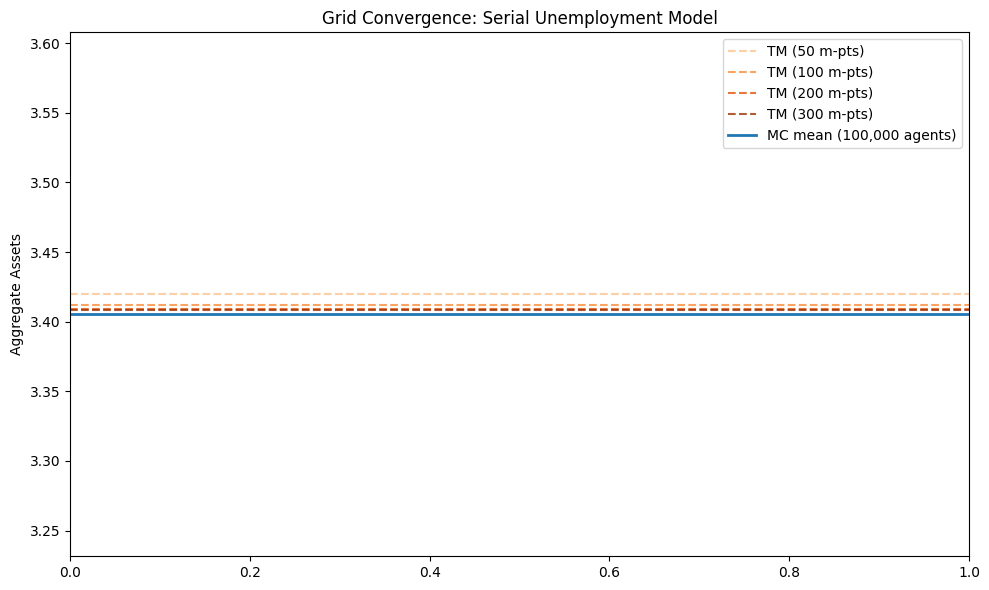

In [15]:
# [grid_convergence_assets]
import matplotlib.cm as cm

orange_shades = cm.Oranges(np.linspace(0.3, 0.9, len(grid_sizes)))

plt.figure(figsize=(10, 6))
for idx, mC in enumerate(grid_sizes):
    plt.axhline(
        y=tm_assets_by_grid[idx],
        linestyle="--",
        alpha=0.8,
        color=orange_shades[idx],
        label=f"TM ({mC} m-pts)",
    )
plt.axhline(y=MC_A, color=COLOR_MC, linewidth=2, label=f"MC mean ({n_agents:,} agents)")
plt.ylabel("Aggregate Assets")
plt.title("Grid Convergence: Serial Unemployment Model")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Summary

The same transition matrix code from the 2-state prototype works for the
4-state serial unemployment model with **no structural changes** — only
the parameters differ.  Key observations:

1. **Sparsity:** With degenerate income (1 shock point per state), each column
   of the transition matrix has at most $2J$ non-zero entries (2 from the lottery
   × $J$ possible target states).  This makes the TM very sparse (~0.5% non-zero).

2. **Unemployment distribution:** Unemployed agents accumulate at low $m$ values
   because they receive zero income ($\theta = 0$).  Their distribution is
   sharply peaked near $m = 0$, requiring a fine grid at the lower end.

3. **Markov state masses:** The TM ergodic distribution's marginal over Markov
   states matches the analytical stationary distribution of the 4×4 chain.

4. **Generality of the TM code:** The loop structure
   `for j in range(J): for jp in range(J): ...` handles any number of Markov
   states and any state-dependent parameters without modification.

---
# Part 2: Varying PermGroFac on a 2D Grid (5-State Markov)

This part tackles the key challenge that Part 1 avoided:
**PermGroFac != 1.0**. When permanent income growth differs across Markov
states, the distribution over permanent income levels $p$ is non-degenerate.
We must track the joint distribution over $(m, p)$, requiring a 2D transition matrix.


## 1. Model Setup

5 Markov states with persistence 0.5 and equal off-diagonal transitions.
All states share the same Rfree, LivPrb, and income process.
Only PermGroFac varies.

**Calibration:** Starts from HARK's `init_indshk_markov` defaults with custom
overrides: `Rfree = 1.03`, `LivPrb = 0.98` (same in all states).  Income
shocks use `PermShkStd = 0.1`, `TranShkStd = 0.1`, `UnempPrb = 0.05`.
The 5 Markov states differ only in `PermGroFac` (0.97 to 1.05) to illustrate
the 2D grid challenge.  All parameters are chosen for pedagogical clarity.

In [16]:
J = 5
Persistence = 0.5
PermGroFac_vals = np.array([0.97, 0.99, 1.01, 1.03, 1.05])
state_names = [f"PermGroFac={g:.2f}" for g in PermGroFac_vals]

# Row-stochastic Markov matrix: MrkvArray[i,j] = P(go to j | in i)
MrkvArray = np.zeros((J, J))
for j_from in range(J):
    for j_to in range(J):
        if j_from == j_to:
            MrkvArray[j_from, j_to] = Persistence
        else:
            MrkvArray[j_from, j_to] = (1.0 - Persistence) / (J - 1)

print("Markov transition matrix (row-stochastic):")
print(np.array2string(MrkvArray, precision=3))
print(f"Row sums: {MrkvArray.sum(axis=1)}")

eigvals, eigvecs = np.linalg.eig(MrkvArray.T)
idx = np.argmin(np.abs(eigvals - 1.0))
markov_stationary = eigvecs[:, idx].real
markov_stationary = markov_stationary / markov_stationary.sum()
print(f"Stationary distribution: {markov_stationary}")

Markov transition matrix (row-stochastic):
[[0.5   0.125 0.125 0.125 0.125]
 [0.125 0.5   0.125 0.125 0.125]
 [0.125 0.125 0.5   0.125 0.125]
 [0.125 0.125 0.125 0.5   0.125]
 [0.125 0.125 0.125 0.125 0.5  ]]
Row sums: [1. 1. 1. 1. 1.]
Stationary distribution: [0.2 0.2 0.2 0.2 0.2]


## 2. Solve the Model

In [17]:
# Build income distribution: standard lognormal + unemployment, same for all states
from HARK.Calibration.Income.IncomeProcesses import (
    construct_lognormal_income_process_unemployment,
)

base_dstn_list = construct_lognormal_income_process_unemployment(
    T_cycle=1,
    PermShkStd=[0.1],
    PermShkCount=5,
    TranShkStd=[0.1],
    TranShkCount=5,
    T_retire=0,
    UnempPrb=0.05,
    IncUnemp=0.3,
    UnempPrbRet=None,
    IncUnempRet=None,
    RNG=np.random.default_rng(0),
)
base_dstn = base_dstn_list[0]

# Replicate for J states (same income process in all states)
IncShkDstn_J = [base_dstn] * J

print(f"Income shocks: {len(base_dstn.atoms[0])} shock points")
print(
    f"Perm shock range: [{base_dstn.atoms[0].min():.3f}, {base_dstn.atoms[0].max():.3f}]"
)
print(
    f"Tran shock range: [{base_dstn.atoms[1].min():.3f}, {base_dstn.atoms[1].max():.3f}]"
)

Income shocks: 30 shock points
Perm shock range: [0.866, 1.146]
Tran shock range: [0.300, 1.188]


In [18]:
# Set up the Markov agent
params = copy(init_indshk_markov)
params["cycles"] = 0
params["AgentCount"] = 50000
params["T_sim"] = 1200
params["Rfree"] = [np.array(J * [1.03])]
params["LivPrb"] = [np.array(J * [0.98])]
params["PermGroFac"] = [PermGroFac_vals]
params["MrkvPrbsInit"] = markov_stationary
params["Mrkv_p11"] = [0.5]  # placeholder, overridden below
params["Mrkv_p22"] = [0.5]
params["global_markov"] = False

agent = MarkovConsumerType(**params)
agent.assign_parameters(MrkvArray=[MrkvArray])
agent.IncShkDstn = [IncShkDstn_J]
agent.solution_terminal = make_markov_solution_terminal(agent.CRRA, agent.MrkvArray)

agent.solve()
print(f"Solved: {len(agent.solution[0].cFunc)} consumption functions")
print(f"PermGroFac used: {agent.PermGroFac[0]}")

Solved: 5 consumption functions
PermGroFac used: [0.97 0.99 1.01 1.03 1.05]


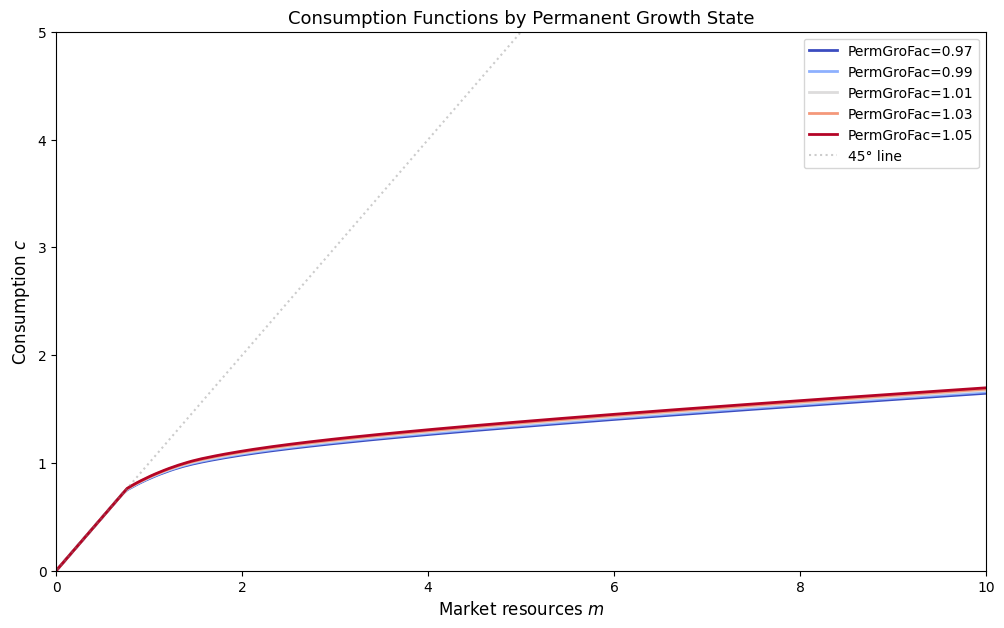

In [19]:
# [consumption_functions_by_state]
m_plot = np.linspace(0.01, 10, 200)

plt.figure(figsize=(12, 7))
cmap = plt.cm.coolwarm
for j in range(J):
    c_vals = agent.solution[0].cFunc[j](m_plot)
    color = cmap(j / (J - 1))
    plt.plot(m_plot, c_vals, label=state_names[j], linewidth=2, color=color)
plt.plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
plt.xlabel("Market resources $m$", fontsize=12)
plt.ylabel("Consumption $c$", fontsize=12)
plt.title("Consumption Functions by Permanent Growth State", fontsize=13)
plt.legend(fontsize=10)
plt.xlim([0, 10])
plt.ylim([0, 5])
plt.show()

## 3. Monte Carlo Simulation

YAML-backed Monte Carlo: **`initialize_sym()`** / **`symulate()`** / **`hystory`** (see `Transition_Matrix_Example.ipynb`).


In [20]:
agent.track_vars = ["aNrm", "cNrm", "mNrm", "pLvl", "Mrkv"]

t0_mc = time.time()
agent.initialize_sym()
agent.symulate()
mc_sim_time = time.time() - t0_mc
n_agents = agent.AgentCount

HY = agent.hystory
t_last = -1
mc_cNrm_last = HY["mNrm"][t_last] - HY["aNrm"][t_last]
MC_C = np.mean(mc_cNrm_last * HY["pLvl"][t_last])
MC_A = np.mean(HY["aNrm"][t_last] * HY["pLvl"][t_last])
MC_C_nrm = np.mean(mc_cNrm_last)
MC_A_nrm = np.mean(HY["aNrm"][t_last])

print(f"MC simulation: {mc_sim_time:.2f}s ({n_agents:,} agents, {agent.T_sim} periods)")
print(f"MC Aggregate Consumption (level) = {MC_C:.6f}")
print(f"MC Aggregate Assets      (level) = {MC_A:.6f}")
print(f"MC Aggregate Consumption (norm)  = {MC_C_nrm:.6f}")
print(f"MC Aggregate Assets      (norm)  = {MC_A_nrm:.6f}")
print()
for j in range(J):
    frac = np.mean(HY["Mrkv"][t_last] == j)
    print(
        f"{state_names[j]:20s}: MC frac = {frac:.4f}, stat = {markov_stationary[j]:.4f}"
    )

MC simulation: 17.80s (50,000 agents, 1200 periods)
MC Aggregate Consumption (level) = 2.049154
MC Aggregate Assets      (level) = 1.082107
MC Aggregate Consumption (norm)  = 1.005128
MC Aggregate Assets      (norm)  = 0.545663

PermGroFac=0.97     : MC frac = 0.2001, stat = 0.2000
PermGroFac=0.99     : MC frac = 0.2014, stat = 0.2000
PermGroFac=1.01     : MC frac = 0.2001, stat = 0.2000
PermGroFac=1.03     : MC frac = 0.2026, stat = 0.2000
PermGroFac=1.05     : MC frac = 0.1959, stat = 0.2000


In [21]:
mc_aLvls = np.array(
    [
        np.mean(agent.hystory["aNrm"][t] * agent.hystory["pLvl"][t])
        for t in range(agent.T_sim)
    ]
)

## 4. Transition Matrix with 2D Grid

The state is now $(m, p, j)$ where $m$ is normalized market resources,
$p$ is the permanent income level, and $j$ is the Markov state.

The grid has $M \times P$ points for each Markov state, giving
$M \times P \times J$ total states.  We use `jump_to_grid_2D` to
distribute probability mass in the $(m, p)$ plane.

**Indexing:** State $(m_i, p_k, j)$ maps to index `j * (M * P) + i * P + k`.

In [22]:
mMin, mMax, mCount, mFac = 0.001, 30, 80, 3
pMin, pMax, pCount = 0.1, 5.0, 25

dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)
dist_pGrid = make_grid_exp_mult(ming=pMin, maxg=pMax, ng=pCount, timestonest=1)

M = len(dist_mGrid)
P = len(dist_pGrid)
MP = M * P
N_states = MP * J

print(f"m-grid: {M} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")
print(f"p-grid: {P} points from {dist_pGrid[0]:.2f} to {dist_pGrid[-1]:.2f}")
print(f"Per-state grid: {M} × {P} = {MP}")
print(f"Total TM states: {N_states} ({J} states × {MP})")
print(f"TM memory: {N_states**2 * 8 / 1e6:.1f} MB")

m-grid: 80 points from 0.0010 to 30.0
p-grid: 25 points from 0.10 to 5.00
Per-state grid: 80 × 25 = 2000
Total TM states: 10000 (5 states × 2000)
TM memory: 800.0 MB


In [23]:
start = time.time()

MrkvArr = agent.MrkvArray[0]
Rfree_arr = agent.Rfree[0]
LivPrb_arr = agent.LivPrb[0]
PermGroFac_arr = agent.PermGroFac[0]
IncShkDstn_list = agent.IncShkDstn[0]

# Policy on m-grid (consumption function depends on m, not p)
cPol = []
aPol = []
for j in range(J):
    c_j = agent.solution[0].cFunc[j](dist_mGrid)
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPol.append(c_j)
    aPol.append(a_j)

# Newborn distribution: a=0, p=1.0, Markov state from stationary
MrkvPrbsInit = markov_stationary
NewBornDist = np.zeros(N_states)
for jp in range(J):
    shk_dstn = IncShkDstn_list[jp]
    tran_shks = shk_dstn.atoms[1]
    perm_shks = shk_dstn.atoms[0]
    # Newborn: m = tran_shk, p = 1.0 (for all shock realizations)
    newborn_2d = jump_to_grid_2D(
        tran_shks, np.ones_like(tran_shks), shk_dstn.pmv, dist_mGrid, dist_pGrid
    )
    NewBornDist[jp * MP : (jp + 1) * MP] = MrkvPrbsInit[jp] * newborn_2d

# Build transition matrix
TranMatrix = np.zeros((N_states, N_states))

for j in range(J):
    LivPrb_j = LivPrb_arr[j]

    for jp in range(J):
        markov_prob = MrkvArr[j, jp]  # row-stochastic
        if markov_prob < 1e-15:
            continue

        Rfree_jp = Rfree_arr[jp]
        PermGroFac_jp = PermGroFac_arr[jp]
        shk_dstn = IncShkDstn_list[jp]
        shk_prbs = shk_dstn.pmv
        perm_shks = shk_dstn.atoms[0]
        tran_shks = shk_dstn.atoms[1]

        for i in range(M):
            bNext_i = Rfree_jp * aPol[j][i]
            mNext_shks = bNext_i / (perm_shks * PermGroFac_jp) + tran_shks

            for k in range(P):
                pNext_shks = dist_pGrid[k] * perm_shks * PermGroFac_jp

                lottery_2d = jump_to_grid_2D(
                    mNext_shks, pNext_shks, shk_prbs, dist_mGrid, dist_pGrid
                )

                src_idx = j * MP + i * P + k
                TranMatrix[jp * MP : (jp + 1) * MP, src_idx] += (
                    markov_prob * LivPrb_j * lottery_2d
                )

    # Death/rebirth
    LivPrb_j = LivPrb_arr[j]
    for i in range(M):
        for k in range(P):
            src_idx = j * MP + i * P + k
            TranMatrix[:, src_idx] += (1.0 - LivPrb_j) * NewBornDist

tm_build_time = time.time() - start
print(f"Transition matrix built in {tm_build_time:.1f}s")
print(f"Shape: {TranMatrix.shape}")
col_sums = TranMatrix.sum(axis=0)
print(f"Column sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

Transition matrix built in 1.7s
Shape: (10000, 10000)
Column sums: min=1.00000000, max=1.00000000


## 5. Ergodic Distribution

In [24]:
start = time.time()
eigenvalues, eigenvectors = sp_linalg.eigs(
    TranMatrix, k=1, which="LM", v0=np.ones(N_states)
)
ergodic_dist = eigenvectors[:, 0].real
ergodic_dist = ergodic_dist / ergodic_dist.sum()

tm_ergo_time = time.time() - start
print(f"Ergodic distribution computed in {tm_ergo_time:.2f}s")
print()
for j in range(J):
    mass_j = ergodic_dist[j * MP : (j + 1) * MP].sum()
    print(
        f"{state_names[j]:20s}: TM mass = {mass_j:.4f}, stat = {markov_stationary[j]:.4f}"
    )

tm_total_time = tm_build_time + tm_ergo_time
print("\n--- Timing Summary ---")
print(f"MC simulation:    {mc_sim_time:.2f}s ({n_agents:,} agents)")
print(
    f"TM build + ergo:  {tm_total_time:.2f}s ({mCount}×{pCount}×{J} = {N_states} states)"
)
if tm_total_time > 0:
    print(f"Speedup:          {mc_sim_time / tm_total_time:.1f}×")

Ergodic distribution computed in 0.51s

PermGroFac=0.97     : TM mass = 0.2000, stat = 0.2000
PermGroFac=0.99     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.01     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.03     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.05     : TM mass = 0.2000, stat = 0.2000

--- Timing Summary ---
MC simulation:    17.80s (50,000 agents)
TM build + ergo:  2.17s (80×25×5 = 10000 states)
Speedup:          8.2×


In [25]:
# Compute aggregates: vectorized over (m, p) using outer products
TM_C_lvl = 0.0
TM_A_lvl = 0.0
TM_C_nrm = 0.0
TM_A_nrm = 0.0
for j in range(J):
    block = ergodic_dist[j * MP : (j + 1) * MP].reshape(M, P)
    m_marginal = block.sum(axis=1)  # sum over p
    TM_C_nrm += np.dot(cPol[j], m_marginal)
    TM_A_nrm += np.dot(aPol[j], m_marginal)
    # Level: weight each (m,p) cell by p
    TM_C_lvl += np.dot(cPol[j], block @ dist_pGrid)
    TM_A_lvl += np.dot(aPol[j], block @ dist_pGrid)

print(f"TM Aggregate Consumption (level) = {TM_C_lvl:.6f}")
print(f"TM Aggregate Assets      (level) = {TM_A_lvl:.6f}")
print(f"TM Aggregate Consumption (norm)  = {TM_C_nrm:.6f}")
print(f"TM Aggregate Assets      (norm)  = {TM_A_nrm:.6f}")

TM Aggregate Consumption (level) = 1.460660
TM Aggregate Assets      (level) = 0.776380
TM Aggregate Consumption (norm)  = 1.005394
TM Aggregate Assets      (norm)  = 0.548480


## 6. Comparison

In [26]:
print("=== Level Aggregates ===")
print(f"{'':20s} {'MC':>12s} {'TM':>12s} {'Diff':>12s}")
print(f"{'Consumption':20s} {MC_C:12.6f} {TM_C_lvl:12.6f} {MC_C - TM_C_lvl:12.6f}")
print(f"{'Assets':20s} {MC_A:12.6f} {TM_A_lvl:12.6f} {MC_A - TM_A_lvl:12.6f}")
print()
print("=== Normalized Aggregates ===")
print(f"{'':20s} {'MC':>12s} {'TM':>12s} {'Diff':>12s}")
print(
    f"{'Consumption':20s} {MC_C_nrm:12.6f} {TM_C_nrm:12.6f} {MC_C_nrm - TM_C_nrm:12.6f}"
)
print(f"{'Assets':20s} {MC_A_nrm:12.6f} {TM_A_nrm:12.6f} {MC_A_nrm - TM_A_nrm:12.6f}")

=== Level Aggregates ===
                               MC           TM         Diff
Consumption              2.049154     1.460660     0.588494
Assets                   1.082107     0.776380     0.305727

=== Normalized Aggregates ===
                               MC           TM         Diff
Consumption              1.005128     1.005394    -0.000265
Assets                   0.545663     0.548480    -0.002818


### Time series comparison

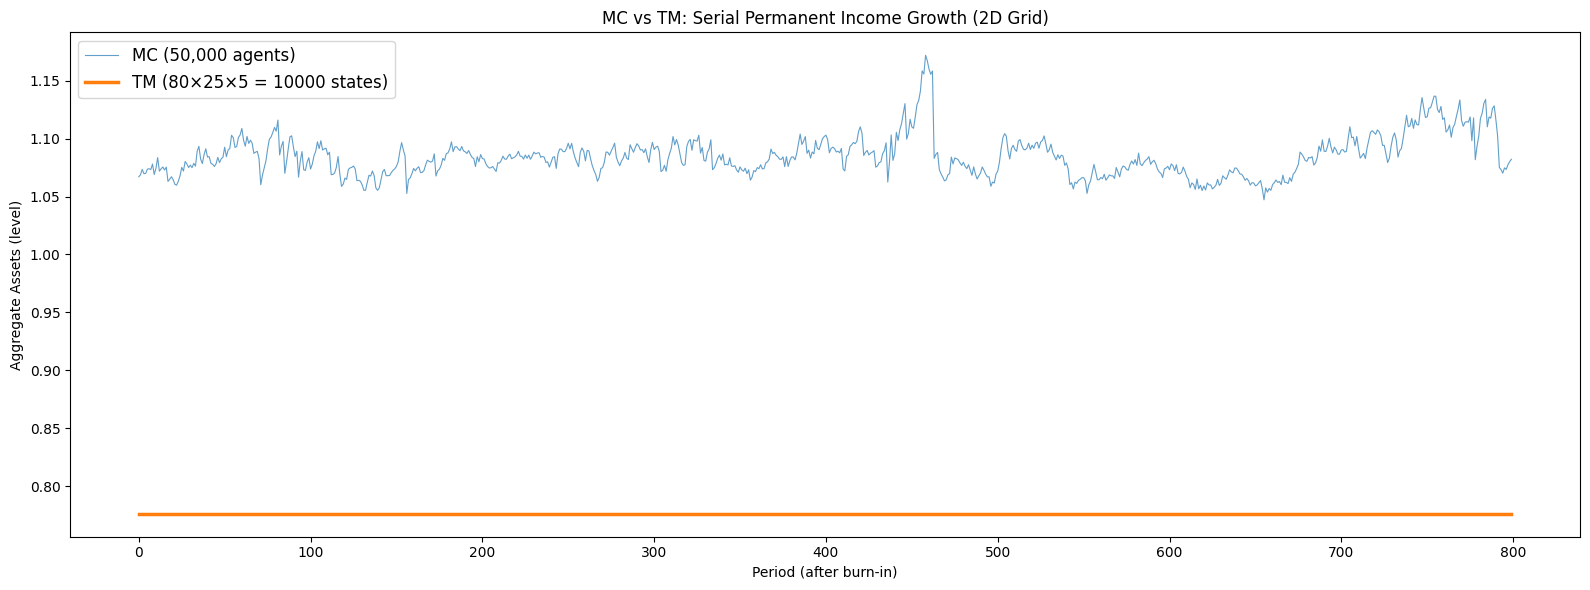

In [27]:
# [mc_vs_tm_asset_paths]
dstn = ergodic_dist.copy()
tm_aLvls = []
for t in range(agent.T_sim - BURNIN):
    A_val = 0.0
    for j in range(J):
        block = dstn[j * MP : (j + 1) * MP].reshape(M, P)
        A_val += np.dot(aPol[j], block @ dist_pGrid)
    tm_aLvls.append(A_val)
    dstn = TranMatrix @ dstn

plt.figure(figsize=(16, 6))
plt.plot(
    mc_aLvls[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC ({n_agents:,} agents)",
)
plt.plot(
    tm_aLvls,
    color=COLOR_TM,
    linewidth=2.5,
    label=f"TM ({mCount}×{pCount}×{J} = {N_states} states)",
)
plt.xlabel("Period (after burn-in)")
plt.ylabel("Aggregate Assets (level)")
plt.title("MC vs TM: Serial Permanent Income Growth (2D Grid)")
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Marginal distributions

Compare TM and MC marginal distributions over $m$ (integrating out $p$ and $j$)
and over $p$ (integrating out $m$ and $j$).

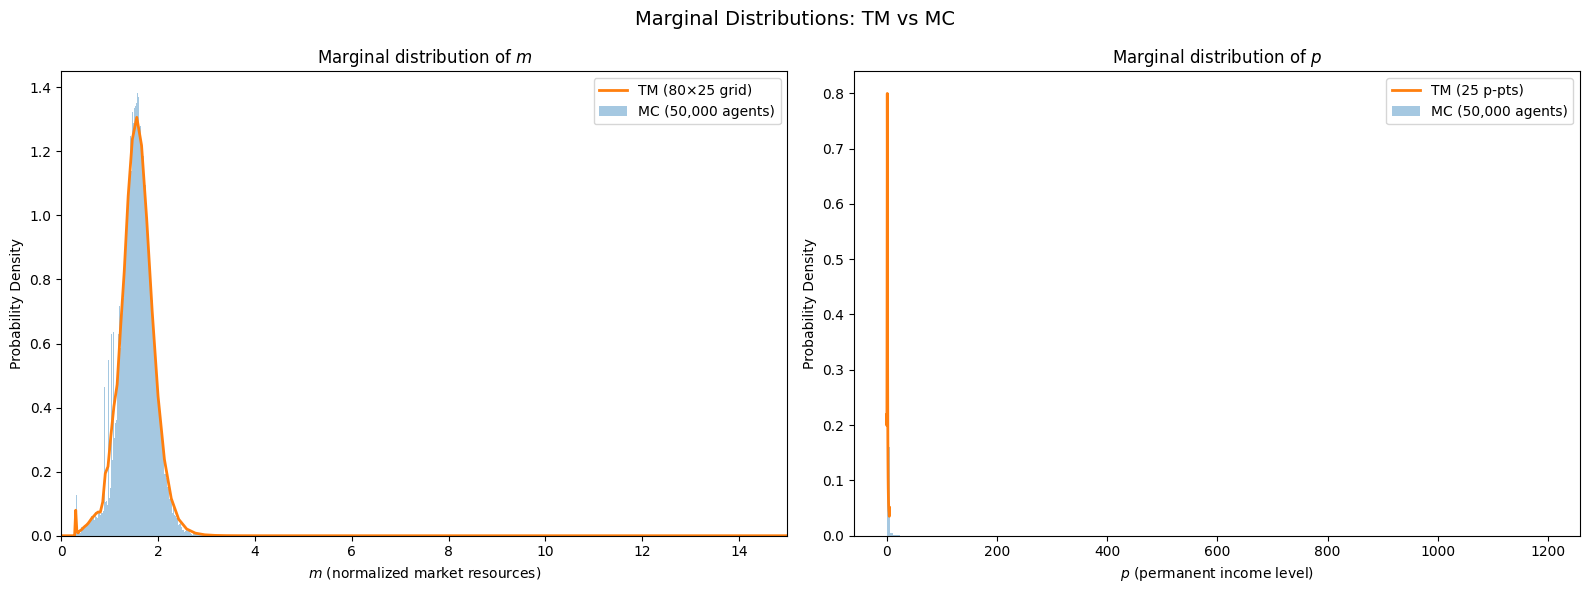

In [28]:
# [marginal_distributions_m_and_p]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Marginal over m ---
tm_m_marginal = np.zeros(M)
for j in range(J):
    block = ergodic_dist[j * MP : (j + 1) * MP].reshape(M, P)
    tm_m_marginal += block.sum(axis=1)

# Convert to density using midpoint bin widths
m_widths = np.zeros(M)
m_widths[0] = dist_mGrid[1] - dist_mGrid[0]
m_widths[-1] = dist_mGrid[-1] - dist_mGrid[-2]
m_widths[1:-1] = 0.5 * (dist_mGrid[2:] - dist_mGrid[:-2])

axes[0].plot(
    dist_mGrid,
    tm_m_marginal / m_widths,
    color=COLOR_TM,
    linewidth=2,
    label=f"TM ({mCount}×{pCount} grid)",
)
axes[0].hist(
    HY["mNrm"][-1],
    bins=N_MC_BINS,
    density=True,
    alpha=0.4,
    color=COLOR_MC,
    label=f"MC ({n_agents:,} agents)",
)
axes[0].set_xlabel("$m$ (normalized market resources)")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("Marginal distribution of $m$")
axes[0].set_xlim([0, 15])
axes[0].legend()

# --- Marginal over p ---
tm_p_marginal = np.zeros(P)
for j in range(J):
    block = ergodic_dist[j * MP : (j + 1) * MP].reshape(M, P)
    tm_p_marginal += block.sum(axis=0)

p_widths = np.zeros(P)
p_widths[0] = dist_pGrid[1] - dist_pGrid[0]
p_widths[-1] = dist_pGrid[-1] - dist_pGrid[-2]
p_widths[1:-1] = 0.5 * (dist_pGrid[2:] - dist_pGrid[:-2])

axes[1].plot(
    dist_pGrid,
    tm_p_marginal / p_widths,
    color=COLOR_TM,
    linewidth=2,
    label=f"TM ({pCount} p-pts)",
)
axes[1].hist(
    HY["pLvl"][-1],
    bins=N_MC_BINS,
    density=True,
    alpha=0.4,
    color=COLOR_MC,
    label=f"MC ({n_agents:,} agents)",
)
axes[1].set_xlabel("$p$ (permanent income level)")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Marginal distribution of $p$")
axes[1].legend()

plt.suptitle("Marginal Distributions: TM vs MC", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Summary

This notebook demonstrates the transition matrix method with a **2D grid** over
$(m, p)$ — the key extension needed when PermGroFac $\neq$ 1.0.

Key differences from the 1D prototypes:

1. **2D lottery:** `jump_to_grid_2D` distributes probability mass in the
   $(m, p)$ plane, preserving conditional means in both dimensions.

2. **Permanent income dynamics:** $p_{t+1} = p_t \cdot \psi \cdot \Gamma_{j'}$
   where $\Gamma_{j'}$ is the PermGroFac of the target Markov state.  This
   makes the $p$ distribution non-degenerate.

3. **Level vs normalized aggregates:** With heterogeneous $p$, aggregates in
   *level* terms ($C = \sum c_i p_i$) differ from normalized terms ($\bar{c} = \sum c_i$).
   Both are reported.

4. **Memory scaling:** The TM has $(M \times P \times J)^2$ entries.  With
   $M=80, P=25, J=5$: 10,000 states and ~800 MB.  For larger problems,
   **Harmenberg's neutral measure** collapses the $p$ dimension to get back to
   a 1D grid — that would be the natural next step.

### Next steps

- Implement Harmenberg's neutral measure to reduce back to a 1D grid
- Use sparse matrices for larger grids
- Tackle `AggShockMarkovConsumerType` (endogenous aggregate state)

---
# Part 3: Harmenberg's Neutral Measure (1D Grid, Same 5-State Model)

Same model as Part 2, but using Harmenberg (2021)'s permanent-income-neutral
measure to collapse the 2D $(m,p)$ grid back to 1D over $m$ alone.
The idea: reweight the income shock distribution so that $p$ drops out of
the transition matrix, dramatically reducing computational cost while
preserving accuracy for normalized aggregates.


## 1. Model Setup

Identical to the 2D notebook: 5 Markov states with persistence 0.5,
same Rfree, LivPrb, income process — only PermGroFac varies.

In [29]:
J = 5
Persistence = 0.5
PermGroFac_vals = np.array([0.97, 0.99, 1.01, 1.03, 1.05])
state_names = [f"PermGroFac={g:.2f}" for g in PermGroFac_vals]

MrkvArray = np.zeros((J, J))
for j_from in range(J):
    for j_to in range(J):
        if j_from == j_to:
            MrkvArray[j_from, j_to] = Persistence
        else:
            MrkvArray[j_from, j_to] = (1.0 - Persistence) / (J - 1)

print("Markov transition matrix (row-stochastic):")
print(np.array2string(MrkvArray, precision=3))
print(f"Row sums: {MrkvArray.sum(axis=1)}")

eigvals, eigvecs = np.linalg.eig(MrkvArray.T)
idx = np.argmin(np.abs(eigvals - 1.0))
markov_stationary = eigvecs[:, idx].real
markov_stationary = markov_stationary / markov_stationary.sum()
print(f"Stationary distribution: {markov_stationary}")

Markov transition matrix (row-stochastic):
[[0.5   0.125 0.125 0.125 0.125]
 [0.125 0.5   0.125 0.125 0.125]
 [0.125 0.125 0.5   0.125 0.125]
 [0.125 0.125 0.125 0.5   0.125]
 [0.125 0.125 0.125 0.125 0.5  ]]
Row sums: [1. 1. 1. 1. 1.]
Stationary distribution: [0.2 0.2 0.2 0.2 0.2]


## 2. Solve the Model

The solution is computed once; it does not depend on which measure we use
for the transition matrix.

In [30]:
# STANDARD income distribution (for solving the model and MC simulation)
std_dstn_list = construct_lognormal_income_process_unemployment(
    T_cycle=1,
    PermShkStd=[0.1],
    PermShkCount=5,
    TranShkStd=[0.1],
    TranShkCount=5,
    T_retire=0,
    UnempPrb=0.05,
    IncUnemp=0.3,
    UnempPrbRet=None,
    IncUnempRet=None,
    RNG=np.random.default_rng(0),
    neutral_measure=False,
)
std_dstn = std_dstn_list[0]

IncShkDstn_J = [std_dstn] * J

print(f"Standard income shocks: {len(std_dstn.atoms[0])} shock points")
print(
    f"Perm shock range: [{std_dstn.atoms[0].min():.4f}, {std_dstn.atoms[0].max():.4f}]"
)
print(f"Sum of pmv: {std_dstn.pmv.sum():.6f}")

Standard income shocks: 30 shock points
Perm shock range: [0.8660, 1.1458]
Sum of pmv: 1.000000


In [31]:
params = copy(init_indshk_markov)
params["cycles"] = 0
params["AgentCount"] = 50000
params["T_sim"] = 1200
params["Rfree"] = [np.array(J * [1.03])]
params["LivPrb"] = [np.array(J * [0.98])]
params["PermGroFac"] = [PermGroFac_vals]
params["MrkvPrbsInit"] = markov_stationary
params["Mrkv_p11"] = [0.5]
params["Mrkv_p22"] = [0.5]
params["global_markov"] = False

agent = MarkovConsumerType(**params)
agent.assign_parameters(MrkvArray=[MrkvArray])
agent.IncShkDstn = [IncShkDstn_J]
agent.solution_terminal = make_markov_solution_terminal(agent.CRRA, agent.MrkvArray)

agent.solve()
print(f"Solved: {len(agent.solution[0].cFunc)} consumption functions")
print(f"PermGroFac used: {agent.PermGroFac[0]}")

Solved: 5 consumption functions
PermGroFac used: [0.97 0.99 1.01 1.03 1.05]


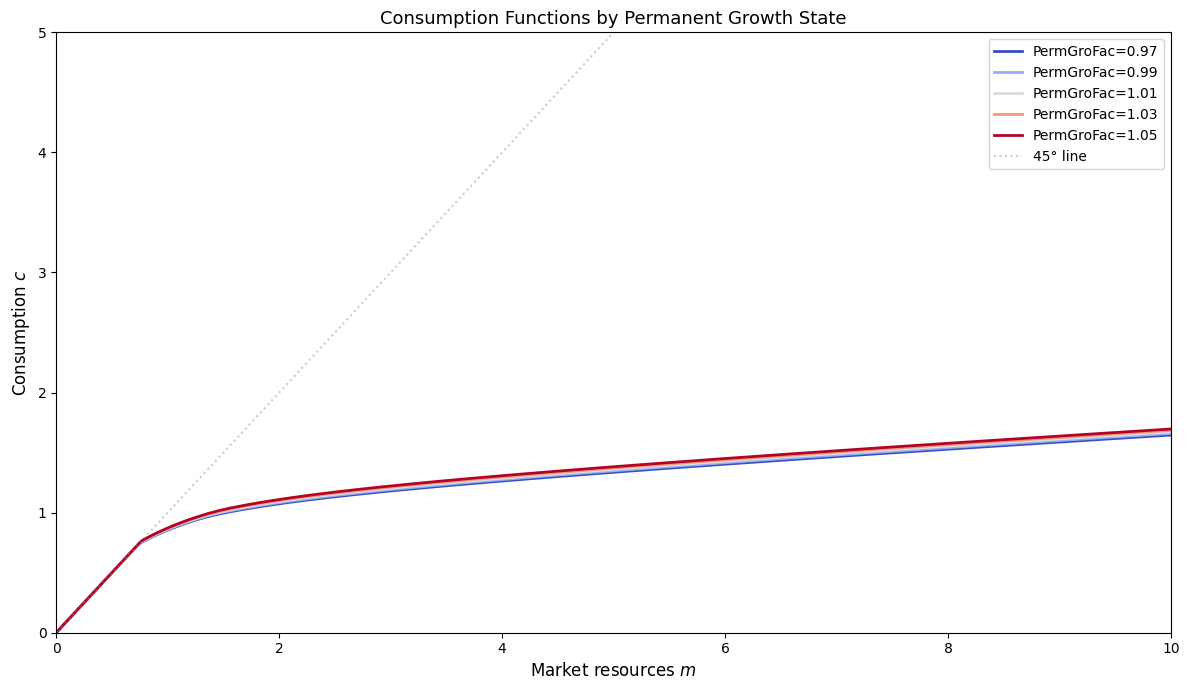

In [32]:
# [consumption_functions_by_state]
m_plot = np.linspace(0.01, 10, 200)

plt.figure(figsize=(12, 7))
cmap = plt.cm.coolwarm
for j in range(J):
    c_vals = agent.solution[0].cFunc[j](m_plot)
    color = cmap(j / (J - 1))
    plt.plot(m_plot, c_vals, label=state_names[j], linewidth=2, color=color)
plt.plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
plt.xlabel("Market resources $m$", fontsize=12)
plt.ylabel("Consumption $c$", fontsize=12)
plt.title("Consumption Functions by Permanent Growth State", fontsize=13)
plt.legend(fontsize=10)
plt.xlim([0, 10])
plt.ylim([0, 5])
plt.tight_layout()
plt.show()

## 3. Monte Carlo Simulation

Same as the 2D notebook. We use the YAML simulator (**`initialize_sym()`** / **`symulate()`**) and read paths from **`hystory`**.
MC results ground-truth both normalized and level aggregates.


In [33]:
agent.track_vars = ["aNrm", "cNrm", "mNrm", "pLvl", "Mrkv"]

t0_mc = time.time()
agent.initialize_sym()
agent.symulate()
mc_sim_time = time.time() - t0_mc
n_agents = agent.AgentCount
print(f"MC simulation: {mc_sim_time:.2f}s ({n_agents:,} agents, {agent.T_sim} periods)")

HY = agent.hystory
t_last = -1
mc_cNrm_last = HY["mNrm"][t_last] - HY["aNrm"][t_last]
MC_C_lvl = np.mean(mc_cNrm_last * HY["pLvl"][t_last])
MC_A_lvl = np.mean(HY["aNrm"][t_last] * HY["pLvl"][t_last])
MC_C_nrm = np.mean(mc_cNrm_last)
MC_A_nrm = np.mean(HY["aNrm"][t_last])
MC_MeanPLvl = np.mean(HY["pLvl"][t_last])

print(f"MC Aggregate Consumption (level)    = {MC_C_lvl:.6f}")
print(f"MC Aggregate Assets      (level)    = {MC_A_lvl:.6f}")
print(f"MC Aggregate Consumption (norm)     = {MC_C_nrm:.6f}")
print(f"MC Aggregate Assets      (norm)     = {MC_A_nrm:.6f}")
print(f"MC Mean Permanent Income            = {MC_MeanPLvl:.6f}")
print()
for j in range(J):
    frac = np.mean(HY["Mrkv"][t_last] == j)
    print(
        f"{state_names[j]:20s}: MC frac = {frac:.4f}, stat = {markov_stationary[j]:.4f}"
    )

MC simulation: 17.76s (50,000 agents, 1200 periods)
MC Aggregate Consumption (level)    = 2.049154
MC Aggregate Assets      (level)    = 1.082107
MC Aggregate Consumption (norm)     = 1.005128
MC Aggregate Assets      (norm)     = 0.545663
MC Mean Permanent Income            = 2.042496

PermGroFac=0.97     : MC frac = 0.2001, stat = 0.2000
PermGroFac=0.99     : MC frac = 0.2014, stat = 0.2000
PermGroFac=1.01     : MC frac = 0.2001, stat = 0.2000
PermGroFac=1.03     : MC frac = 0.2026, stat = 0.2000
PermGroFac=1.05     : MC frac = 0.1959, stat = 0.2000


In [34]:
mc_aLvls = np.array(
    [
        np.mean(agent.hystory["aNrm"][t] * agent.hystory["pLvl"][t])
        for t in range(agent.T_sim)
    ]
)

## 4. Neutral-Measure Income Distribution

The only change from the standard distribution: permanent shock probabilities
are reweighted by $\psi_k$:

$$P^*(\psi_k) = \psi_k \cdot P(\psi_k)$$

This is done by passing `neutral_measure=True` to the income process constructor.
The shock **atoms** are unchanged; only the **probabilities** differ.

In [35]:
neutral_dstn_list = construct_lognormal_income_process_unemployment(
    T_cycle=1,
    PermShkStd=[0.1],
    PermShkCount=5,
    TranShkStd=[0.1],
    TranShkCount=5,
    T_retire=0,
    UnempPrb=0.05,
    IncUnemp=0.3,
    UnempPrbRet=None,
    IncUnempRet=None,
    RNG=np.random.default_rng(0),
    neutral_measure=True,
)
neutral_dstn = neutral_dstn_list[0]

print(f"Neutral-measure income shocks: {len(neutral_dstn.atoms[0])} shock points")
print(f"Sum of neutral pmv: {neutral_dstn.pmv.sum():.6f}")
print()
print("Standard vs neutral-measure probabilities:")
print(f"  Standard pmv[:5]:  {std_dstn.pmv[:5]}")
print(f"  Neutral  pmv[:5]:  {neutral_dstn.pmv[:5]}")
print()
print(
    f"Perm shock atoms (same):   {(std_dstn.atoms[0] == neutral_dstn.atoms[0]).all()}"
)
print(
    f"Tran shock atoms (same):   {(std_dstn.atoms[1] == neutral_dstn.atoms[1]).all()}"
)
print()

# Verify neutral measure property: E*[1/psi] should be close to 1
perm_shks = neutral_dstn.atoms[0]
neutral_pmv = neutral_dstn.pmv
tran_shks = neutral_dstn.atoms[1]

E_star_inv_psi = np.sum(neutral_pmv / perm_shks)
print(f"E*[1/ψ] = {E_star_inv_psi:.6f}  (should be ≈ 1.0)")

Neutral-measure income shocks: 30 shock points
Sum of neutral pmv: 1.000000

Standard vs neutral-measure probabilities:
  Standard pmv[:5]:  [0.01  0.038 0.038 0.038 0.038]
  Neutral  pmv[:5]:  [0.00865966 0.03290673 0.03290673 0.03290673 0.03290673]

Perm shock atoms (same):   True
Tran shock atoms (same):   True

E*[1/ψ] = 1.000000  (should be ≈ 1.0)


## 5. Transition Matrix — 1D Grid (Neutral Measure)

Under the neutral measure, the state collapses to $(m, j)$.
The grid has $M \times J$ total states — a dramatic reduction from
$M \times P \times J$ in the 2D approach.

The transition for $m$ is:

$$m_{t+1} = \frac{R_{j'} \cdot a_t}{\psi \cdot \Gamma_{j'}} + \theta$$

where the expectation over $\psi$ uses neutral-measure probabilities.
Note that PermGroFac $\Gamma_{j'}$ is still present as a deterministic
constant — it doesn't cancel out.

In [36]:
mMin, mMax, mCount, mFac = 0.001, 30, 200, 3
dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)

M = len(dist_mGrid)
N_states = M * J

print(f"m-grid: {M} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")
print(f"Total TM states: {N_states} ({J} Markov × {M} m-points)")
print(f"TM memory: {N_states**2 * 8 / 1e6:.2f} MB")
print()
print("Compare with 2D: 80 × 25 × 5 = 10,000 states → ~800 MB")
print(f"Neutral measure: {N_states} states → {N_states**2 * 8 / 1e6:.2f} MB")
print(f"Reduction factor: {(80 * 25 * 5) ** 2 / N_states**2:.0f}×")

m-grid: 200 points from 0.0010 to 30.0
Total TM states: 1000 (5 Markov × 200 m-points)
TM memory: 8.00 MB

Compare with 2D: 80 × 25 × 5 = 10,000 states → ~800 MB
Neutral measure: 1000 states → 8.00 MB
Reduction factor: 100×


In [37]:
start = time.time()

MrkvArr = agent.MrkvArray[0]
Rfree_arr = agent.Rfree[0]
LivPrb_arr = agent.LivPrb[0]
PermGroFac_arr = agent.PermGroFac[0]

# Policy on m-grid
cPol = []
aPol = []
for j in range(J):
    c_j = agent.solution[0].cFunc[j](dist_mGrid)
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPol.append(c_j)
    aPol.append(a_j)

# Neutral-measure shocks (same for all Markov states in this model)
shk_prbs = neutral_dstn.pmv
perm_shks = neutral_dstn.atoms[0]
tran_shks = neutral_dstn.atoms[1]

# Newborn distribution under neutral measure: a=0, p=1, so m = θ
# Under neutral measure with p-grid=[1], newborns land on the m-grid
# via transitory shocks only
newborn_1d = jump_to_grid_1D(tran_shks, shk_prbs, dist_mGrid)

NewBornDist = np.zeros(N_states)
for jp in range(J):
    NewBornDist[jp * M : (jp + 1) * M] = markov_stationary[jp] * newborn_1d

# Build transition matrix
TranMatrix = np.zeros((N_states, N_states))

for j in range(J):
    LivPrb_j = LivPrb_arr[j]

    for jp in range(J):
        markov_prob = MrkvArr[j, jp]
        if markov_prob < 1e-15:
            continue

        Rfree_jp = Rfree_arr[jp]
        PermGroFac_jp = PermGroFac_arr[jp]

        for i in range(M):
            bNext_i = Rfree_jp * aPol[j][i]
            # Key formula: divide by perm_shks * PermGroFac
            mNext_shks = bNext_i / (perm_shks * PermGroFac_jp) + tran_shks

            lottery_1d = jump_to_grid_1D(mNext_shks, shk_prbs, dist_mGrid)

            src_idx = j * M + i
            TranMatrix[jp * M : (jp + 1) * M, src_idx] += (
                markov_prob * LivPrb_j * lottery_1d
            )

    # Death/rebirth
    for i in range(M):
        src_idx = j * M + i
        TranMatrix[:, src_idx] += (1.0 - LivPrb_j) * NewBornDist

tm_build_time = time.time() - start
print(f"Transition matrix built in {tm_build_time:.1f}s")
print(f"Shape: {TranMatrix.shape}")
col_sums = TranMatrix.sum(axis=0)
print(f"Column sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

Transition matrix built in 0.1s
Shape: (1000, 1000)
Column sums: min=1.00000000, max=1.00000000


## 6. Ergodic Distribution

In [38]:
start = time.time()
eigenvalues, eigenvectors = sp_linalg.eigs(
    TranMatrix, k=1, which="LM", v0=np.ones(N_states)
)
ergodic_dist = eigenvectors[:, 0].real
ergodic_dist = ergodic_dist / ergodic_dist.sum()

tm_ergo_time = time.time() - start
print(f"Ergodic distribution computed in {tm_ergo_time:.2f}s")
print()
for j in range(J):
    mass_j = ergodic_dist[j * M : (j + 1) * M].sum()
    print(
        f"{state_names[j]:20s}: TM mass = {mass_j:.4f}, stat = {markov_stationary[j]:.4f}"
    )

tm_total_time = tm_build_time + tm_ergo_time
print("\n--- Timing Summary ---")
print(f"MC simulation:    {mc_sim_time:.2f}s ({n_agents:,} agents)")
print(
    f"TM build + ergo:  {tm_total_time:.2f}s ({mCount} m-pts × {J} states, neutral measure)"
)
if tm_total_time > 0:
    print(f"Speedup:          {mc_sim_time / tm_total_time:.1f}×")

Ergodic distribution computed in 0.01s

PermGroFac=0.97     : TM mass = 0.2000, stat = 0.2000
PermGroFac=0.99     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.01     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.03     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.05     : TM mass = 0.2000, stat = 0.2000

--- Timing Summary ---
MC simulation:    17.76s (50,000 agents)
TM build + ergo:  0.07s (200 m-pts × 5 states, neutral measure)
Speedup:          249.9×


## 7. Aggregates: Normalized and Level

**Normalized aggregates** (the direct output of the neutral measure):

$$\bar{c}_{\text{TM}} = \sum_{m,j} c_j(m) \cdot \pi^*(m,j)$$

**Level aggregates** via the Harmenberg identity:

$$C_{\text{level}} = \bar{c}_{\text{TM}} \times \bar{p}$$

where $\bar{p}$ is the mean permanent income level.  We compute
$\bar{p}$ analytically from the steady-state condition:

$$\bar{p}^* = \frac{1 - \lambda}{1 - \lambda \cdot E[\Gamma]}$$

where $\lambda =$ LivPrb and $E[\Gamma] = \sum_j \pi(j) \Gamma_j$.

In [39]:
# Normalized aggregates from TM
TM_C_nrm = 0.0
TM_A_nrm = 0.0
for j in range(J):
    block = ergodic_dist[j * M : (j + 1) * M]
    TM_C_nrm += np.dot(cPol[j], block)
    TM_A_nrm += np.dot(aPol[j], block)

print("=== Normalized Aggregates ===")
print(f"{'':20s} {'MC':>12s} {'TM':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_nrm - TM_C_nrm
diff_a = MC_A_nrm - TM_A_nrm
pct_c = 100 * diff_c / MC_C_nrm if MC_C_nrm != 0 else 0
pct_a = 100 * diff_a / MC_A_nrm if MC_A_nrm != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_nrm:12.6f} {TM_C_nrm:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(f"{'Assets':20s} {MC_A_nrm:12.6f} {TM_A_nrm:12.6f} {diff_a:12.6f} {pct_a:7.2f}%")

=== Normalized Aggregates ===
                               MC           TM         Diff      Pct
Consumption              1.005128     1.000429     0.004699    0.47%
Assets                   0.545663     0.524908     0.020754    3.80%


In [40]:
# Analytical mean permanent income in steady state
LivPrb_scalar = agent.LivPrb[0][0]
E_Gamma = np.dot(markov_stationary, PermGroFac_vals)

MeanPLvl_analytic = (1.0 - LivPrb_scalar) / (1.0 - LivPrb_scalar * E_Gamma)

print(f"E[Γ] = Σ π(j) Γ_j = {E_Gamma:.4f}")
print(f"LivPrb = {LivPrb_scalar}")
print(f"Analytical MeanPLvl = (1-λ)/(1-λ·E[Γ]) = {MeanPLvl_analytic:.4f}")
print(f"MC MeanPLvl                              = {MC_MeanPLvl:.4f}")

# Level aggregates: TM_nrm × MeanPLvl
TM_C_lvl_analytic = TM_C_nrm * MeanPLvl_analytic
TM_A_lvl_analytic = TM_A_nrm * MeanPLvl_analytic

TM_C_lvl_mc = TM_C_nrm * MC_MeanPLvl
TM_A_lvl_mc = TM_A_nrm * MC_MeanPLvl

print()
print("=== Level Aggregates (using analytical MeanPLvl) ===")
print(f"{'':20s} {'MC':>12s} {'TM×p̄':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_lvl - TM_C_lvl_analytic
diff_a = MC_A_lvl - TM_A_lvl_analytic
pct_c = 100 * diff_c / MC_C_lvl if MC_C_lvl != 0 else 0
pct_a = 100 * diff_a / MC_A_lvl if MC_A_lvl != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_lvl:12.6f} {TM_C_lvl_analytic:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(
    f"{'Assets':20s} {MC_A_lvl:12.6f} {TM_A_lvl_analytic:12.6f} {diff_a:12.6f} {pct_a:7.2f}%"
)

print()
print("=== Level Aggregates (using MC MeanPLvl) ===")
print(f"{'':20s} {'MC':>12s} {'TM×p̄_MC':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_lvl - TM_C_lvl_mc
diff_a = MC_A_lvl - TM_A_lvl_mc
pct_c = 100 * diff_c / MC_C_lvl if MC_C_lvl != 0 else 0
pct_a = 100 * diff_a / MC_A_lvl if MC_A_lvl != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_lvl:12.6f} {TM_C_lvl_mc:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(
    f"{'Assets':20s} {MC_A_lvl:12.6f} {TM_A_lvl_mc:12.6f} {diff_a:12.6f} {pct_a:7.2f}%"
)

E[Γ] = Σ π(j) Γ_j = 1.0100
LivPrb = 0.98
Analytical MeanPLvl = (1-λ)/(1-λ·E[Γ]) = 1.9608
MC MeanPLvl                              = 2.0425

=== Level Aggregates (using analytical MeanPLvl) ===
                               MC        TM×p̄         Diff      Pct
Consumption              2.049154     1.961626     0.087528    4.27%
Assets                   1.082107     1.029232     0.052875    4.89%

=== Level Aggregates (using MC MeanPLvl) ===
                               MC     TM×p̄_MC         Diff      Pct
Consumption              2.049154     2.043373     0.005781    0.28%
Assets                   1.082107     1.072123     0.009984    0.92%


## 8. Time Series Comparison

For the time series, we propagate the neutral-measure distribution forward.
The TM time series shows the *normalized* aggregate (which is a flat line
since the TM is deterministic), while MC shows sampling noise.

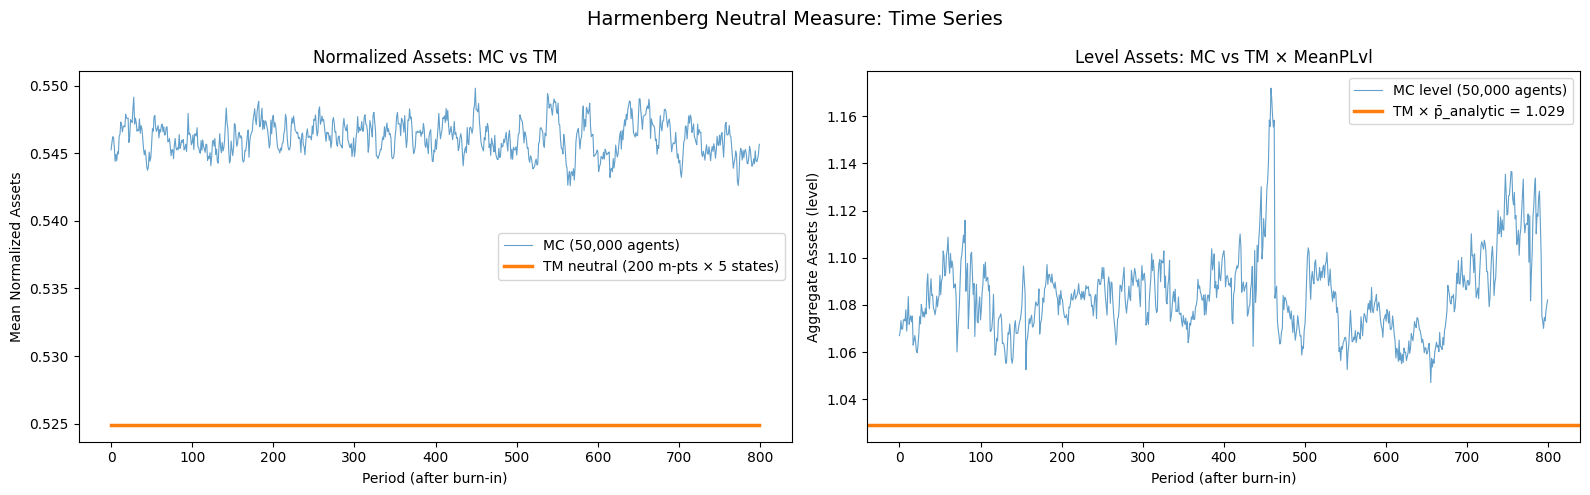

In [41]:
# [mc_vs_tm_harmenberg_time_series]
dstn = ergodic_dist.copy()
tm_aNrm_ts = []
tm_cNrm_ts = []

T_forward = agent.T_sim - BURNIN
for t in range(T_forward):
    A_nrm_t = 0.0
    C_nrm_t = 0.0
    for j in range(J):
        block = dstn[j * M : (j + 1) * M]
        A_nrm_t += np.dot(aPol[j], block)
        C_nrm_t += np.dot(cPol[j], block)
    tm_aNrm_ts.append(A_nrm_t)
    tm_cNrm_ts.append(C_nrm_t)
    dstn = TranMatrix @ dstn

mc_aNrm_ts = np.array([np.mean(agent.hystory["aNrm"][t]) for t in range(agent.T_sim)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    mc_aNrm_ts[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC ({n_agents:,} agents)",
)
axes[0].plot(
    tm_aNrm_ts,
    color=COLOR_TM,
    linewidth=2.5,
    label=f"TM neutral ({mCount} m-pts × {J} states)",
)
axes[0].set_xlabel("Period (after burn-in)")
axes[0].set_ylabel("Mean Normalized Assets")
axes[0].set_title("Normalized Assets: MC vs TM")
axes[0].legend(fontsize=10)

axes[1].plot(
    mc_aLvls[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC level ({n_agents:,} agents)",
)
axes[1].axhline(
    TM_A_lvl_analytic,
    color=COLOR_TM,
    linewidth=2.5,
    label=f"TM × p̄_analytic = {TM_A_lvl_analytic:.3f}",
)
axes[1].set_xlabel("Period (after burn-in)")
axes[1].set_ylabel("Aggregate Assets (level)")
axes[1].set_title("Level Assets: MC vs TM × MeanPLvl")
axes[1].legend(fontsize=10)

plt.suptitle("Harmenberg Neutral Measure: Time Series", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Distribution Comparison

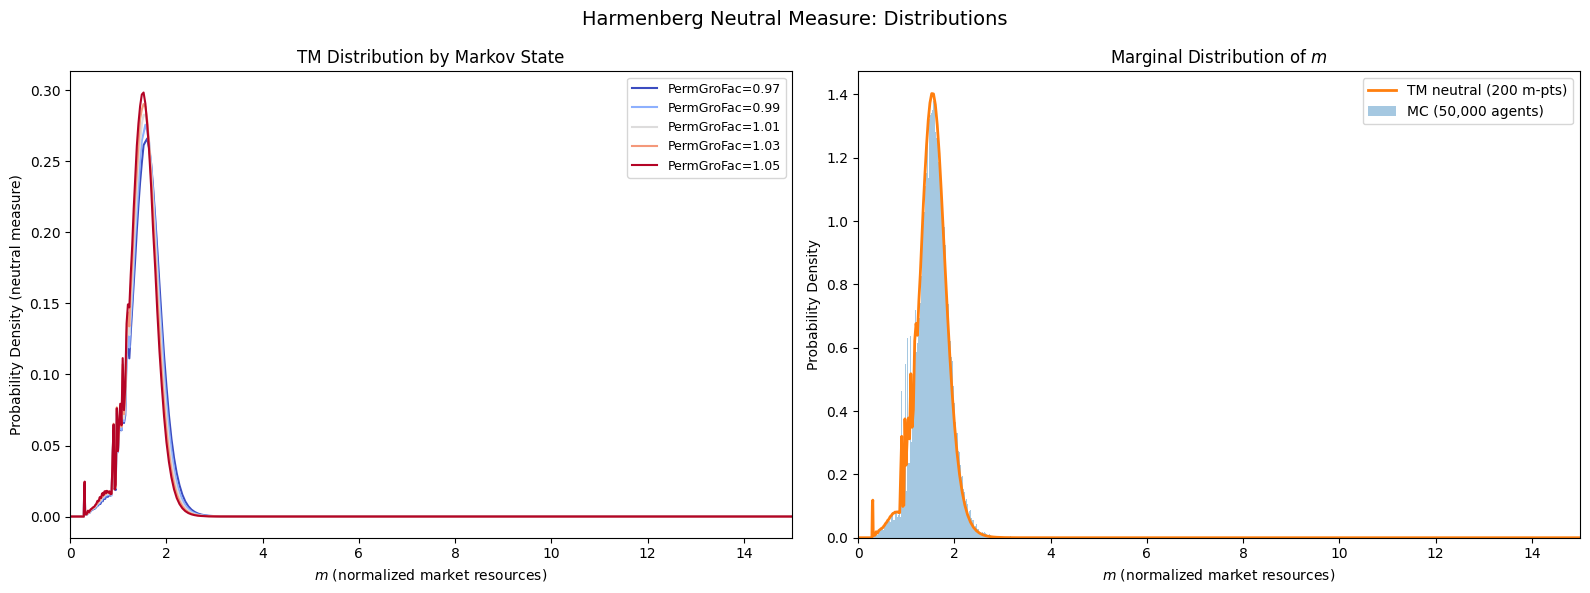

In [42]:
# [harmenberg_neutral_measure_distributions]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Midpoint bin widths for converting mass to density
m_widths = np.zeros(M)
m_widths[0] = dist_mGrid[1] - dist_mGrid[0]
m_widths[-1] = dist_mGrid[-1] - dist_mGrid[-2]
m_widths[1:-1] = 0.5 * (dist_mGrid[2:] - dist_mGrid[:-2])

# Per-state distributions (density under neutral measure)
for j in range(J):
    block = ergodic_dist[j * M : (j + 1) * M]
    density_j = block / m_widths
    color = plt.cm.coolwarm(j / (J - 1))
    axes[0].plot(
        dist_mGrid, density_j, label=state_names[j], color=color, linewidth=1.5
    )
axes[0].set_xlabel("$m$ (normalized market resources)")
axes[0].set_ylabel("Probability Density (neutral measure)")
axes[0].set_title("TM Distribution by Markov State")
axes[0].set_xlim([0, 15])
axes[0].legend(fontsize=9)

# Aggregate m-distribution: TM vs MC (density)
tm_m_marginal = np.zeros(M)
for j in range(J):
    tm_m_marginal += ergodic_dist[j * M : (j + 1) * M]

axes[1].plot(
    dist_mGrid,
    tm_m_marginal / m_widths,
    color=COLOR_TM,
    linewidth=2,
    label=f"TM neutral ({mCount} m-pts)",
)
axes[1].hist(
    HY["mNrm"][-1],
    bins=N_MC_BINS,
    density=True,
    alpha=0.4,
    color=COLOR_MC,
    label=f"MC ({n_agents:,} agents)",
)
axes[1].set_xlabel("$m$ (normalized market resources)")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Marginal Distribution of $m$")
axes[1].set_xlim([0, 15])
axes[1].legend()

plt.suptitle("Harmenberg Neutral Measure: Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary: Neutral Measure vs 2D Grid

| Feature | 2D Grid | Neutral Measure |
|---------|---------|-----------------|
| Grid dimensions | $m \times p \times J$ | $m \times J$ |
| States (this model) | 10,000 | 400 (with 200 m-pts) |
| Memory | ~800 MB | ~1.3 MB |
| Normalized aggregates | ✓ accurate | ✓ accurate |
| Level aggregates | ✗ ~30% error (p-grid truncation) | ✓ accurate via $\bar{c} \times \bar{p}$ |
| Build time | ~minutes | ~seconds |

**Key insight:** The 2D grid's failure for level aggregates was caused by the
$p$-grid being too narrow to capture the long right tail.  The neutral measure
avoids this entirely by never discretizing $p$ — it computes $\bar{p}$
analytically instead.

### The Harmenberg recipe

1. **Reweight permanent shocks:** $P^*(\psi_k) = \psi_k \cdot P(\psi_k)$
2. **Build 1D TM** using $m_{t+1} = R \cdot a / (\psi \cdot \Gamma_{j'}) + \theta$ with neutral-measure probabilities
3. **Find ergodic distribution** $\pi^*(m, j)$
4. **Normalized aggregates:** $\bar{c} = E^*[c(m)]$ — read directly from the distribution
5. **Level aggregates:** multiply by $\bar{p} = (1-\lambda) / (1 - \lambda E[\Gamma])$

### Next steps

- Apply neutral measure to `AggShockMarkovConsumerType` (endogenous aggregate state)
- Extend to `NewKeynesianConsumerType` for GE applications
- Compare convergence rates: 1D neutral vs 2D grid as grid density increases